# Bar plot

Fundamentals and guides for creating better bar plots with Matplotlib using kaggle G20 Countries Development Indicators at https://www.kaggle.com/datasets/kalacheva/g20-countries-development-indicators

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [6]:
g20 = pd.read_csv('data/world_development.csv').drop('Series Code', axis=1)
g20.head()

,Country Name,Country Code,Series Name,YR2014,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,R2023
0,Argentina,ARG,"Adolescent fertility rate (births per 1,000 wo...",66.613,63.879,58.79,55.022,49.926,41.751,31.492,28.54,25.767,..
1,Argentina,ARG,"Agriculture, forestry, and fishing, value adde...",6.71270351428559,5.1566859021408,6.26456582010254,5.23162237725058,4.53787889681146,5.3185559967348,6.35703367575527,7.29128249622041,6.63829697473642,5.92985376183283
2,Argentina,ARG,"Annual freshwater withdrawals, total (% of int...",12.9075342465753,12.9075342465753,12.9075342465753,12.9075342465753,12.9075342465753,12.9075342465753,12.9075342465753,12.9075342465753,..,..
3,Argentina,ARG,Births attended by skilled health staff (% of ...,99.6,99.6,98.4,93.9,99.5,99.6,98.8,..,..,..
4,Argentina,ARG,"Contraceptive prevalence, any method (% of mar...",..,..,..,..,..,..,70.1,..,..,..


In [4]:
country_to_continents = {
    "Argentina": "America",
    "Australia": "Oceania",
    "Brazil": "America",
    "Canada": "America",
    "China": "Asia",
    "France": "Europe",
    "Germany": "Europe", 
    "India": "Asia", 
    "Indonesia": "Oceania", 
    "Italy": "Europe", 
    "Japan": "Asia", 
    "Korea, Rep.": "Asia",
    "Mexico": "America",
    "Netherlands": "Europe",
    "Russian Federation": "Europe", 
    "Saudi Arabia": "Asia", 
    "Switzerland": "Europe",
    "Turkiye": "Asia",
    "United Kingdom": "Europe",
    "United States": "America",
    "Spain": "Europe"
}

In [5]:
g20['Continent'] = g20['Country Name'].map(country_to_continents)
g20['Continent'].unique()

array(['America', 'Oceania', 'Asia', 'Europe'], dtype=object)

Reshaping dataframe from Wide to Long:

In [6]:
g20_long = g20.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Continent'],
    var_name='Year',
    value_name='Value',
)
g20_long

,Country Name,Country Code,Series Name,Continent,Year,Value
0,Argentina,ARG,"Adolescent fertility rate (births per 1,000 wo...",America,YR2014,66.613
1,Argentina,ARG,"Agriculture, forestry, and fishing, value adde...",America,YR2014,6.71270351428559
2,Argentina,ARG,"Annual freshwater withdrawals, total (% of int...",America,YR2014,12.9075342465753
3,Argentina,ARG,Births attended by skilled health staff (% of ...,America,YR2014,99.6
4,Argentina,ARG,"Contraceptive prevalence, any method (% of mar...",America,YR2014,..
...,...,...,...,...,...,...
10595,United States,USA,Tax revenue (% of GDP),America,R2023,10.2238066854639
10596,United States,USA,Terrestrial and marine protected areas (% of t...,America,R2023,..
10597,United States,USA,Time required to start a business (days),America,R2023,..
10598,United States,USA,"Total debt service (% of exports of goods, ser...",America,R2023,..


In [7]:
g20_long['Series Name'].unique()

array(['Adolescent fertility rate (births per 1,000 women ages 15-19)',
       'Agriculture, forestry, and fishing, value added (% of GDP)',
       'Annual freshwater withdrawals, total (% of internal resources)',
       'Births attended by skilled health staff (% of total)',
       'Contraceptive prevalence, any method (% of married women ages 15-49)',
       'Domestic credit provided by financial sector (% of GDP)',
       'Electric power consumption (kWh per capita)',
       'Energy use (kg of oil equivalent per capita)',
       'Exports of goods and services (% of GDP)',
       'External debt stocks, total (DOD, current US$)',
       'Fertility rate, total (births per woman)',
       'Foreign direct investment, net inflows (BoP, current US$)',
       'Forest area (sq. km)', 'GDP (current US$)',
       'GDP growth (annual %)',
       'GNI per capita, Atlas method (current US$)',
       'GNI per capita, PPP (current international $)',
       'GNI, Atlas method (current US$)',
       

In [8]:
g20_long['Year'].unique()

array(['YR2014', 'YR2015', 'YR2016', 'YR2017', 'YR2018', 'YR2019',
       'YR2020', 'YR2021', 'YR2022', 'R2023'], dtype=object)

In [9]:
pop2021 = g20_long.loc[(g20_long['Year'] == 'YR2021') & (g20_long['Series Name'] == 'Population, total')]
pop2021['Value'] = pop2021['Value'].apply(int)
pop2021

,Country Name,Country Code,Series Name,Continent,Year,Value
7457,Argentina,ARG,"Population, total",America,YR2021,45312281
7510,Australia,AUS,"Population, total",Oceania,YR2021,25685412
7563,Brazil,BRA,"Population, total",America,YR2021,209550294
7616,China,CHN,"Population, total",Asia,YR2021,1412360000
7669,France,FRA,"Population, total",Europe,YR2021,67842811
7722,Germany,DEU,"Population, total",Europe,YR2021,83196078
7775,India,IND,"Population, total",Asia,YR2021,1414203896
7828,Indonesia,IDN,"Population, total",Oceania,YR2021,276758053
7881,Italy,ITA,"Population, total",Europe,YR2021,59133173
7934,Japan,JPN,"Population, total",Asia,YR2021,125681593


# 1. Basic Bar Plot

<BarContainer object of 20 artists>

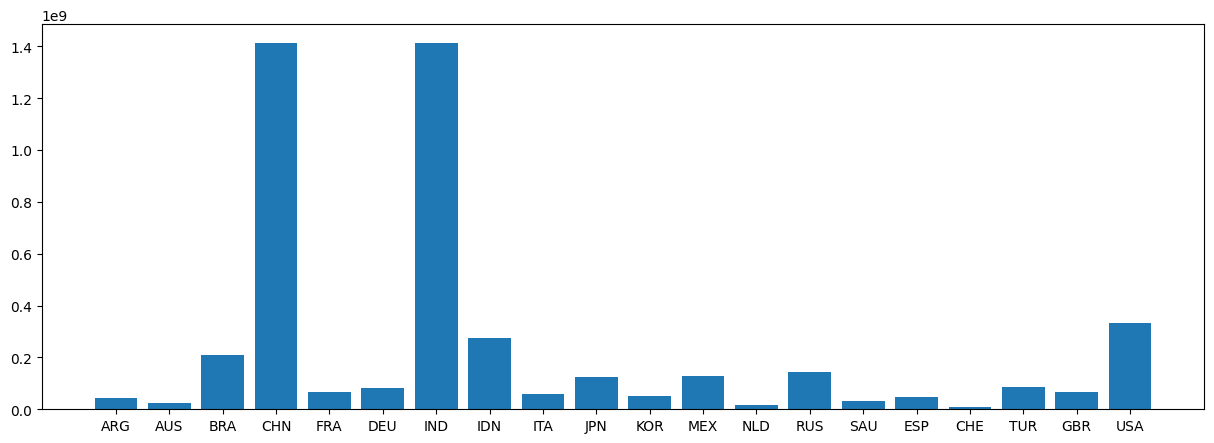

In [10]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x=pop2021['Country Code'], height=pop2021['Value'])

# 2. Change y scale to millions

<BarContainer object of 20 artists>

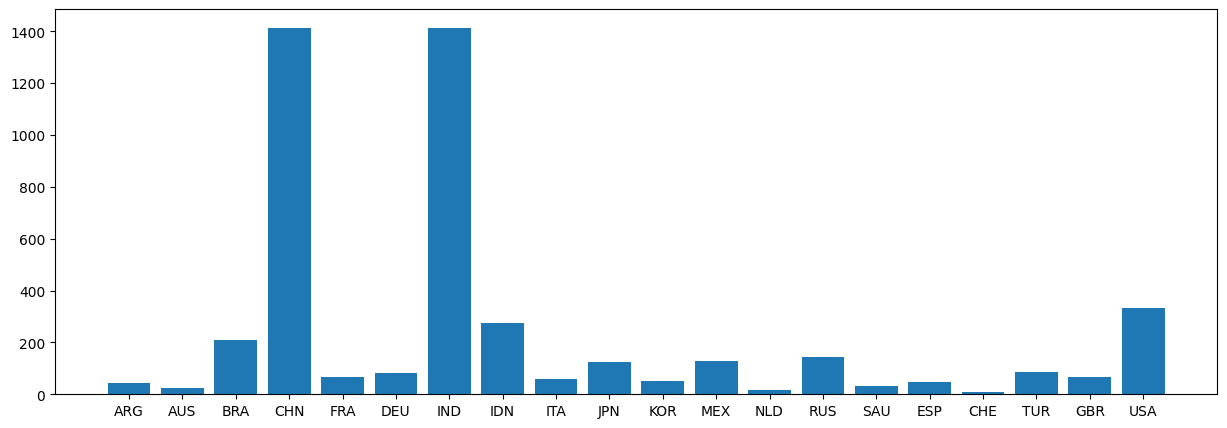

In [11]:
pop2021['Value'] = pop2021['Value'] / 1e6
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x=pop2021['Country Code'], height=pop2021['Value'])

# 3. Adding title and labels

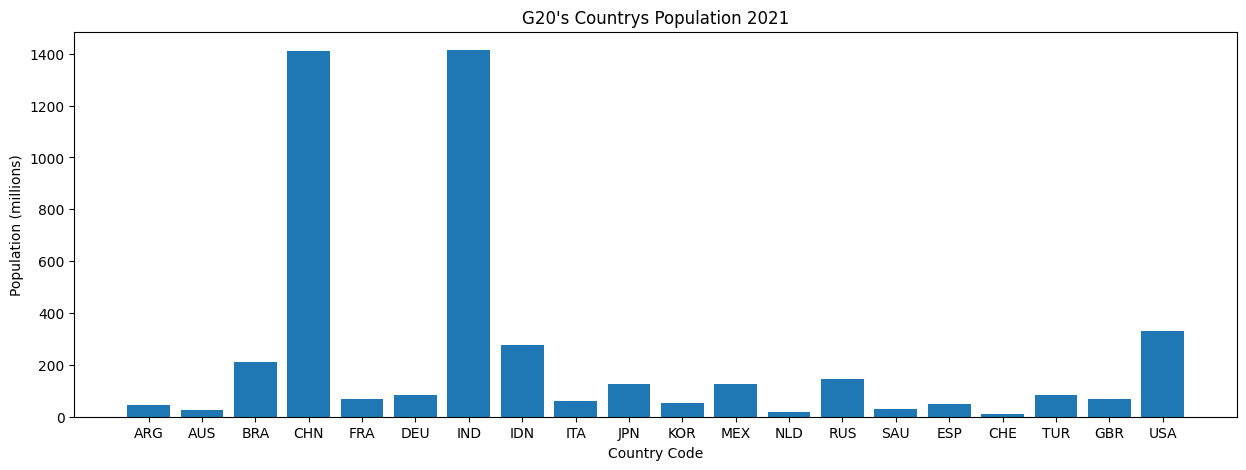

In [12]:
ax.set_title('G20\'s Countrys Population 2021')
ax.set_ylabel('Population (millions)')
ax.set_xlabel('Country Code')
fig

# 4. Changing Bars colors

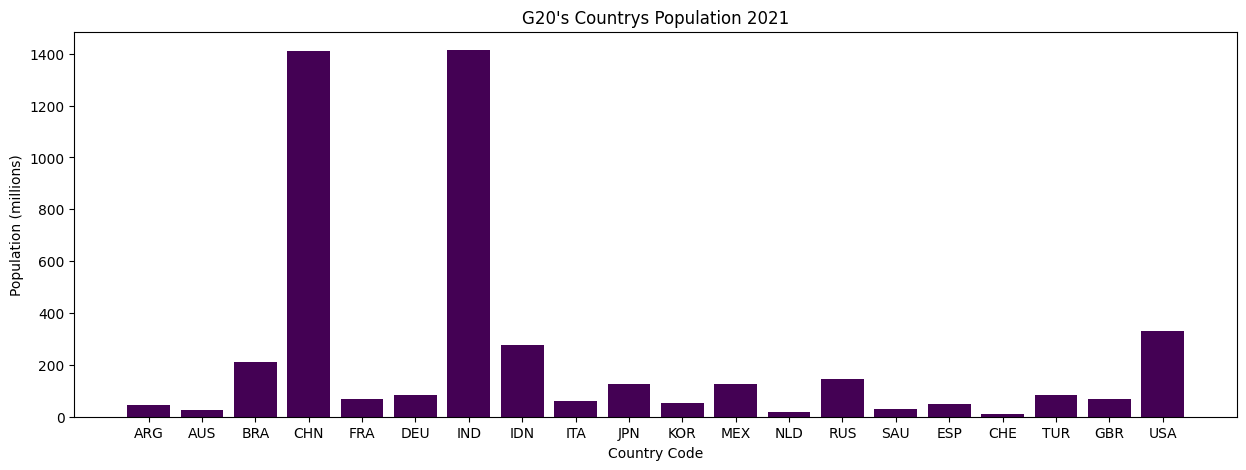

In [13]:
vcmap = plt.get_cmap('viridis', 6)
ax.bar(x=pop2021['Country Code'], height=pop2021['Value'], color=vcmap(0))
fig

# 5. Adding bars values

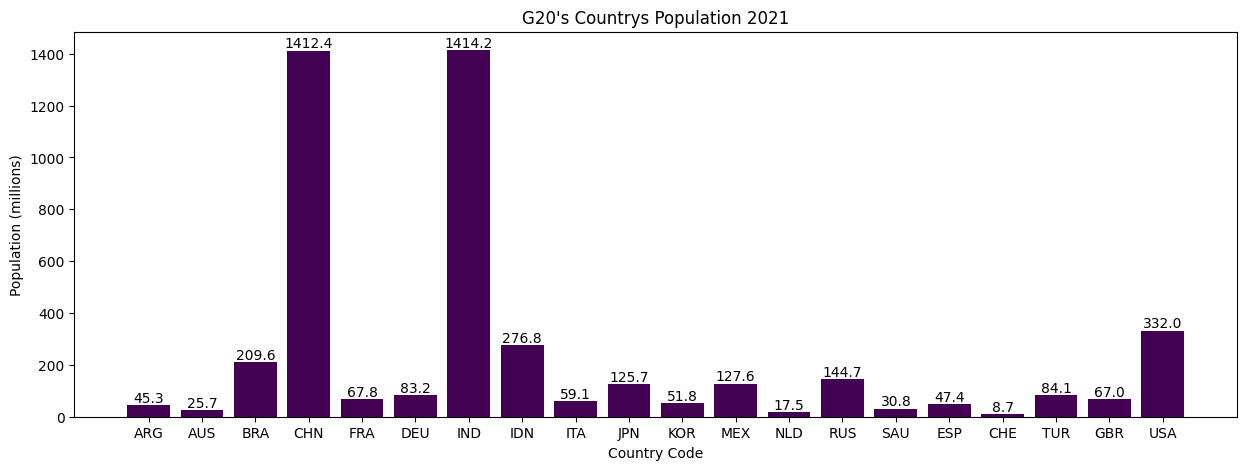

In [14]:
ax.bar_label(ax.containers[0], fmt="%.1f")
fig

# 6. Sorted bar chart with the highest value highlighted

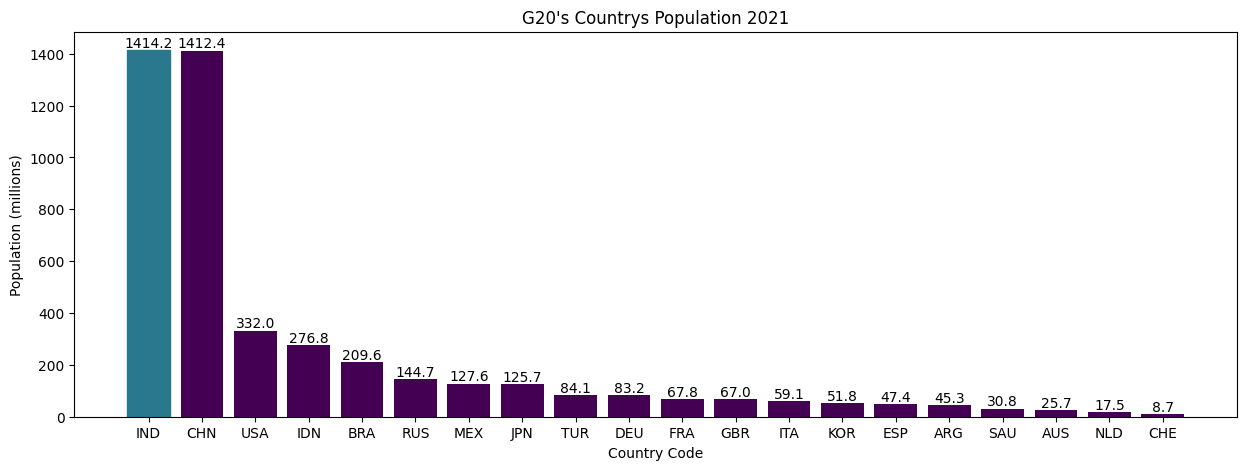

In [15]:
pop2021_sorted = pop2021.sort_values('Value', ascending=False)
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x=pop2021_sorted['Country Code'], height=pop2021_sorted['Value'], color=vcmap(0))
ax.set_title('G20\'s Countrys Population 2021')
ax.set_ylabel('Population (millions)')
ax.set_xlabel('Country Code')
ax.bar_label(ax.containers[0], fmt="%.1f")
ax.containers[0][0].set_color(vcmap(2))

# 7. Bar subplots divided by Continent

In [19]:
countrys_per_continent = pop2021.groupby('Continent').size()
countrys_per_continent

Continent
America    4
Asia       6
Europe     8
Oceania    2
dtype: int64

Text(0.5, 0.98, "G20's Countrys Population 2021")

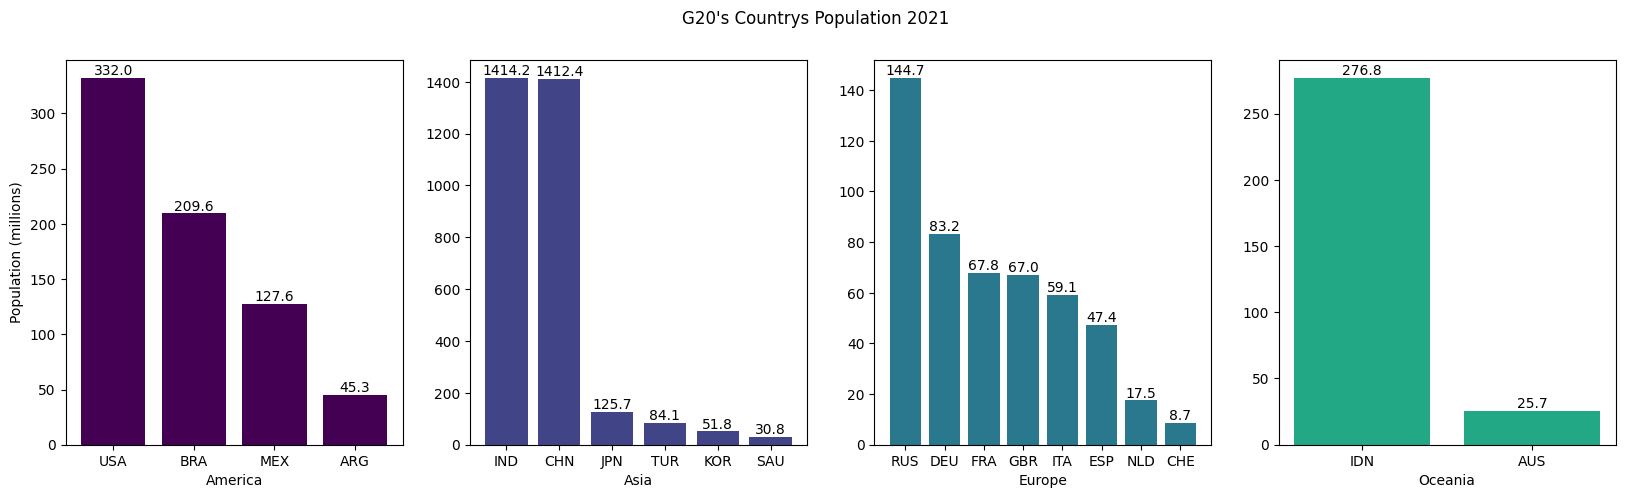

In [22]:
fig, ax = plt.subplots(1, countrys_per_continent.shape[0], figsize=(20, 5))
for i in range(countrys_per_continent.shape[0]):
    continent = countrys_per_continent.index[i]
    continent_slice = pop2021_sorted.loc[pop2021_sorted['Continent'] == continent]
    ax[i].bar(x=continent_slice['Country Code'], height=continent_slice['Value'], color=vcmap(i))
    ax[i].set_xlabel(continent)
    ax[i].bar_label(ax[i].containers[0], fmt="%.1f")

ax[0].set_ylabel('Population (millions)')
fig.suptitle('G20\'s Countrys Population 2021')